# Random Forest & XGBoost Classification: Bank Marketing Classification

### Workflow

1. Feature engineering
2. Train Test Split
3. Train the model
4. Hyperparameter tuning
5. Assess model performance
6. Rerun with XGBoost


## Import Packages

In [1]:
# Data Processing
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Modelling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# Tree Visualization
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Extract dataset from the UCI database

In [2]:
#UCI dataset repo
bank_data = fetch_ucirepo(id=222)

# Extract clean DataFrames
df = bank_data.data.features.copy()
y = bank_data.data.targets.copy()

In [3]:
# metadata 
print(bank_data.metadata) 
  
# variable information 
print(bank_data.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [4]:
#drop the duration column as it was flagged as a leakage feature in the documentation

In [5]:
df = df.drop(columns=['duration', 'contact', 'poutcome', 'education', 'job'])

In [6]:
df.columns

Index(['age', 'marital', 'default', 'balance', 'housing', 'loan',
       'day_of_week', 'month', 'campaign', 'pdays', 'previous'],
      dtype='object')

In [7]:
df.isna().sum()

age            0
marital        0
default        0
balance        0
housing        0
loan           0
day_of_week    0
month          0
campaign       0
pdays          0
previous       0
dtype: int64

# 1. Feature Engineering

Converts Yes/No strings to numeric 1/0 values

In [8]:
# Map binary yes/no columns BEFORE selecting categorical columns
df['default'] = df['default'].map({'no':0, 'yes':1, 'unknown':0})
df['housing'] = df['housing'].map({'no':0, 'yes':1})
df['loan'] = df['loan'].map({'no':0, 'yes':1})

# Map target
y['y'] = y['y'].map({'no':0, 'yes':1})

# Identify categorical columns AFTER mapping
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)



Categorical columns: ['marital', 'month']


# 2. Train Test Split

In [9]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    df, y['y'], test_size=0.2, random_state=42, stratify=y['y']
)

# Preprocess categorical columns
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

# 3. Train the model

In [10]:
# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluate Initial Model

In [11]:
# Predict
y_pred = rf.predict(X_test_processed)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.885104500718788


### Classification Report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.52      0.19      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.71      0.58      0.61      9043
weighted avg       0.86      0.89      0.86      9043



### Confusion Matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7800  185]
 [ 854  204]]


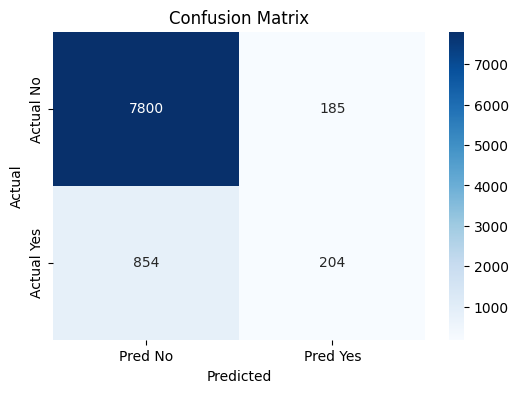

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC AUC

In [15]:
# Get probability of class 1 ("yes")
y_prob = rf.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

ROC AUC: 0.7645976683597435


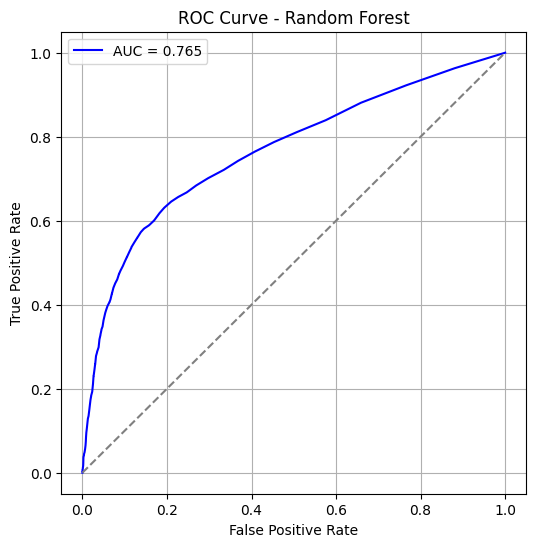

In [16]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='blue')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# Visualizing the Results

### Visualize the first 3 trees

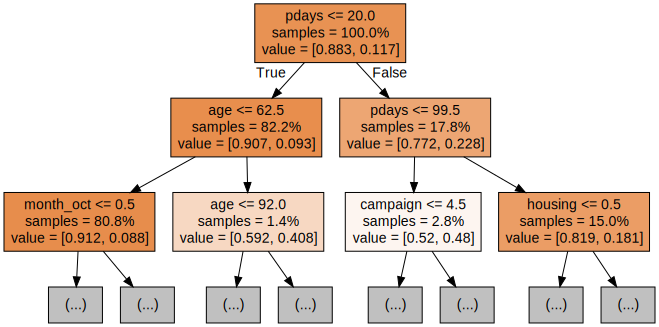

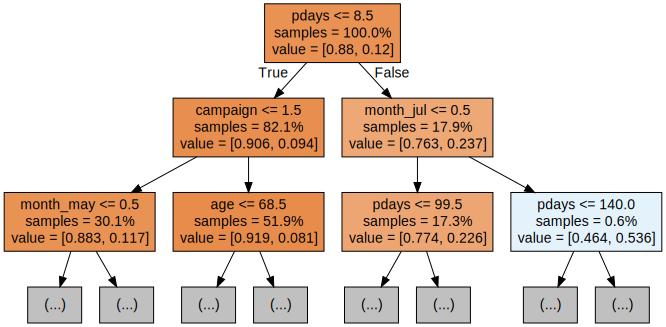

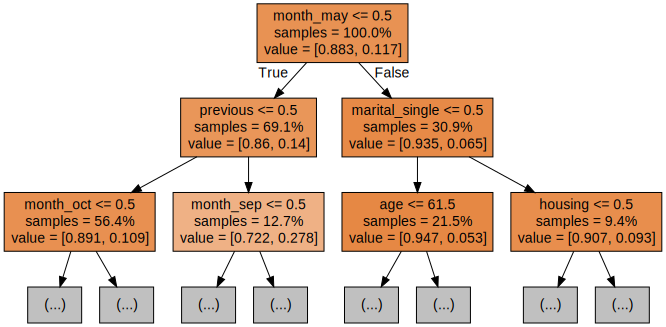

In [17]:
# Export the decision trees from the forest

# 1. Get encoded categorical feature names
encoded_feature_names = preprocess.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# 2. Get numeric passthrough columns
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# 3. Combine them
all_feature_names = list(encoded_feature_names) + numeric_cols

# 4. Visualize trees
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(
        tree,
        feature_names=all_feature_names,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True
    )
    graph = graphviz.Source(dot_data)
    display(graph)


# 4. Hyperparameter Tuning

The code below uses Scikit‑Learn’s RandomizedSearchCV, which performs a randomized search over a defined hyperparameter space. Instead of exhaustively testing every possible combination, it samples from the ranges you specify in the param_dist dictionary. In this setup, we’re tuning two key Random Forest hyperparameters:

• n_estimators — the number of trees in the forest.
Increasing this generally improves model stability and performance, but it also raises the computational cost for both training and prediction.

• max_depth — the maximum depth allowed for each individual tree.
A deeper tree can capture more complex patterns but is more prone to overfitting. A shallow tree may generalize better but risks underfitting if set too low.



In [18]:
param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}


# Create a random forest classifier
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='f1',
  n_jobs=-1, random_state=42)

In [19]:
# Fit randomized search
rand_search.fit(X_train_processed, y_train)

# The single best RandomForestClassifier found during the search
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 413}


# 5. Assess Tuned Model Performance

### Confusion Matrix

Is the model’s predictions compare to the actual outcomes. It highlights the balance between false positives (top‑right corner) and false negatives (bottom‑left corner). 

In [20]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test_processed)


cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7878  107]
 [ 912  146]]


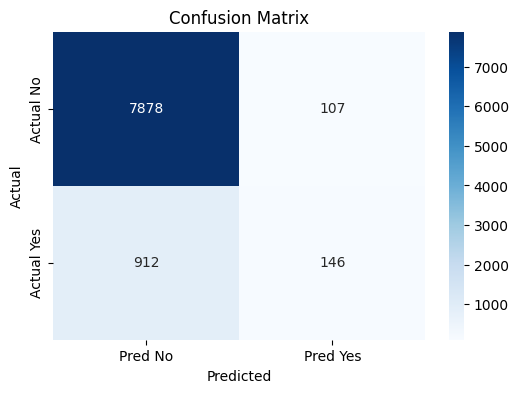

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.58      0.14      0.22      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.56      0.58      9043
weighted avg       0.86      0.89      0.86      9043



In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.887316156142873
Precision: 0.5770750988142292
Recall: 0.13799621928166353


### ROC AUC

In [24]:
# Get probability of class 1 ("yes")
y_prob = best_rf.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

ROC AUC: 0.7858091080511308


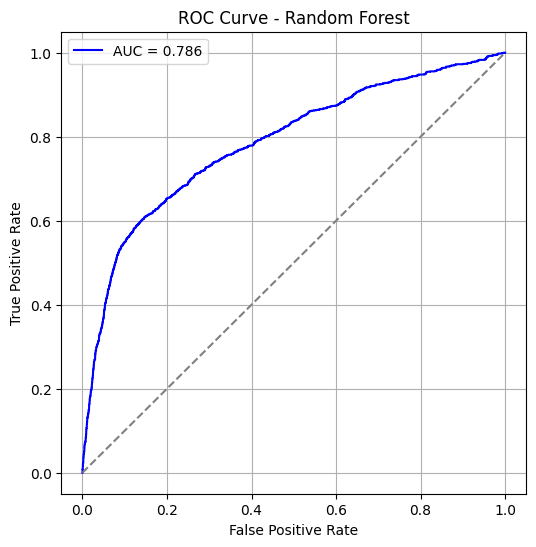

In [25]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='blue')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

### Model Feature Importance

In [26]:
# Create a series containing feature importances from the model and feature names from the training data
# Encoded categorical feature names
encoded_feature_names = preprocess.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Numeric passthrough columns
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Combine
all_feature_names = list(encoded_feature_names) + numeric_cols

feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

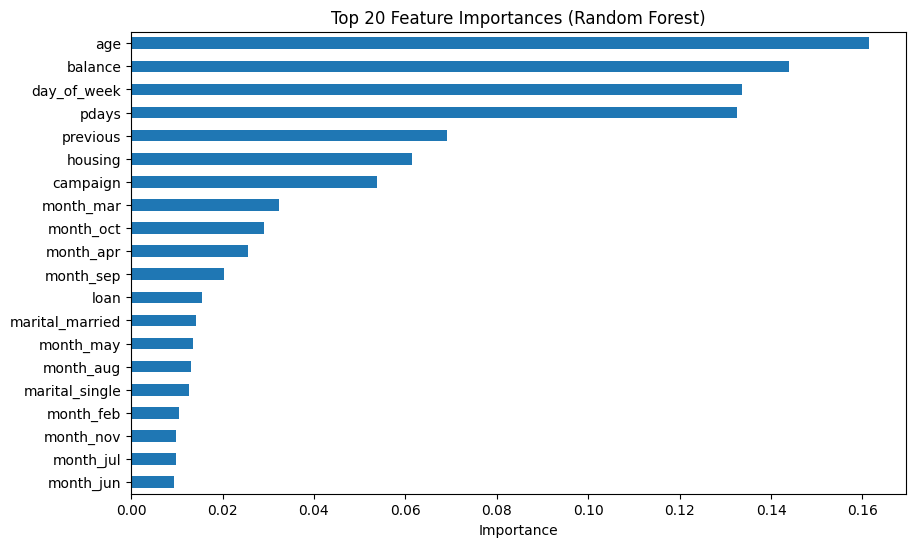

In [27]:
plt.figure(figsize=(10,6))
feature_importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


# 6. Rerun with XGBoost

In [28]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_processed, y_train)

y_pred_xgb = xgb.predict(X_test_processed)
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

y_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC AUC:", auc_xgb)

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.55      0.23      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.60      0.63      9043
weighted avg       0.86      0.89      0.87      9043

[[7790  195]
 [ 816  242]]
ROC AUC: 0.7833614066071427


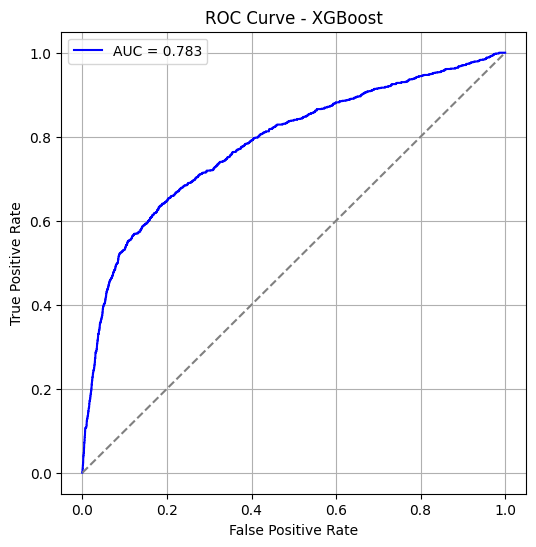

In [29]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,6))
plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_xgb:.3f}", color='blue')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# Discussion


1. The strongest substantive finding is that prior contact history (pdays, previous) outranks most demographic and job-related features. This suggests that whether and when a client was reached before is a stronger predictor of subscribing than who they are demographically, a plausible and business-relevant insight: repeat engagement may matter more than targeting by profile alone.

2. XGBoost, untuned, outperformed both RF versions on the minority class.
Recall of 0.26 and f1 of 0.36 beat both the baseline RF and the tuned RF, despite XGBoost getting zero tuning. ROC AUC was comparable across all three models (~0.78-0.79), so the real difference isn't separability, it's how each model behaves at the default classification threshold. That's a meaningful, specific claim, not just "XGBoost is better."

3. Class imbalance (~88/12) is the dominant challenge, not the choice of algorithm.
Every model struggles with the same thing: precision on class 1 stays moderate (0.57-0.73) while recall keeps collapsing. This is the actual next problem to solve, not more algorithm-swapping. Worth naming class_weight='balanced', scale_pos_weight for XGBoost, or resampling (SMOTE) as the logical next step, even if you don't implement it in this version.

